# 7. Uçtan Uca Örnek (QnA)

               UÇTAN UCA SORU-CEVAP MODELİ SİMÜLASYONU

--- Adım 1: Girdileri Vektörlere Dönüştürme (Embedding) ---
Bağlam 'ankaranın başkent olması süreci türkiye cumhuriyetinin kuruluşuyla doğrudan bağlantılı olup hem stratejik hem de sembolik yönleriyle büyük önem taşımaktadır osmanlı imparatorluğunun 30 ekim 1918 tarihli mondros mütarekesiyle fiilen sona erdiği kabul edilen dönemde istanbul her ne kadar resmen başkent statüsünü koruyor olsa da 16 mart 1920 tarihinde itilaf devletlerinin istanbulu resmen işgal etmesiyle birlikte siyasi bir merkez olma niteliğini yitirmiştir özellikle işgal güçlerinin meclisi mebusanı dağıtması ve osmanlı hükümetini kontrol altına alması üzerine mustafa kemal paşa öncülüğünde başlayan milli mücadele hareketi anadolunun güvenli ve stratejik bir bölgesinde yeni bir merkez ihtiyacını doğurmuştur bu bağlamda 27 aralık 1919 tarihinde mustafa kemal paşanın heyeti temsiliye üyeleriyle birlikte ankaraya gelişi hem sembolik hem de pratik açıdan bir dönüm nokt

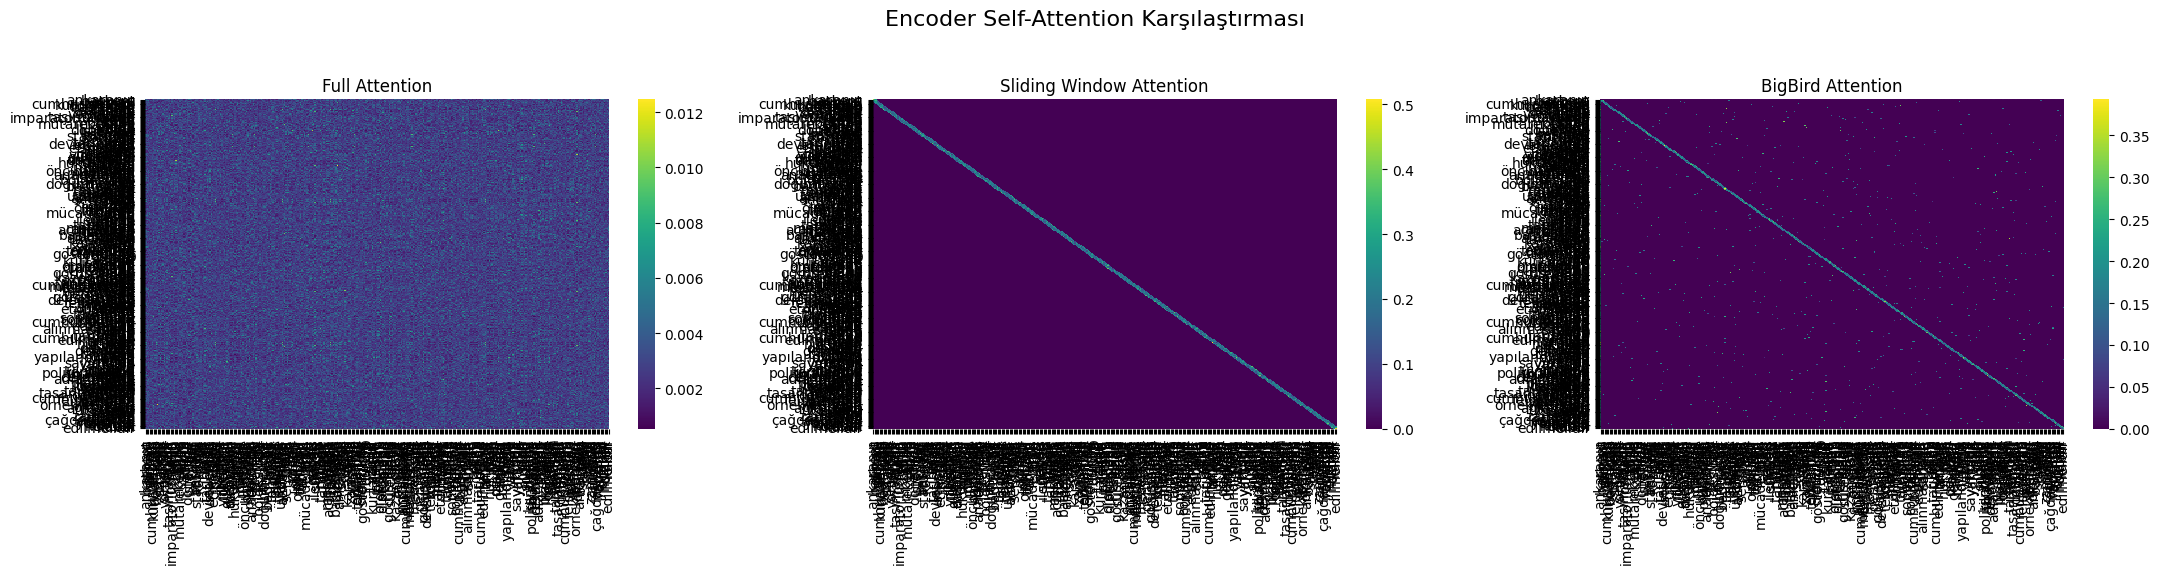


>>> FlashAttention Notu: Yukarıdaki dikkat matrislerinden herhangi biri, hesaplama sırasında
    GPU'nun yavaş HBM'i yerine hızlı SRAM'ini kullanan FlashAttention algoritması ile
    çok daha hızlı bir şekilde (sonuç değişmeden) hesaplanabilir.

Simülasyonun devamı için BigBird Attention çıktısı seçildi.

--- Adım 3: Feed-Forward Network (FFN) ---
Attention katmanından gelen bilgi, FFN katmanında 'işlenir' ve zenginleştirilir.
Standart FFN: Tüm parametreler her token için kullanılır. Maliyetli ama basittir.
Mixture of Experts: Her token için sadece en iyi 'k' uzman (toplam 4 uzmandan 2'si) çalışır.
                  Daha fazla kapasite, daha az hesaplama maliyeti demektir.
Simülasyonun devamı için MoE FFN çıktısı seçildi.

===> ENCODER AŞAMASI TAMAMLANDI. Bağlamın anlamsal temsili hazır.


============================== DECODER AŞAMASI ==============================
Amaç: Soruyu ve işlenmiş bağlamı kullanarak cevabı kelime kelime üretmek.


--- Adım 4.1: Cevabın 1. Kelimesi Üretiliyor

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# =============================================================================
# BÖLÜM 1: YARDIMCI FONKSİYONLAR VE MODÜLLER
# Önceki kodlarımızdan bildiğimiz yapı taşlarını oluşturalım.
# =============================================================================

# --- Maske oluşturma fonksiyonları ---
def create_sliding_window_mask(size, window):
    mask = torch.full((size, size), float('-inf'))
    for i in range(size):
        start, end = max(0, i - window), min(size, i + window + 1)
        mask[i, start:end] = 0
    return mask

def create_bigbird_mask(size, window, num_random, global_indices):
    # BigBird, 3 maskenin birleşimidir
    window_mask = create_sliding_window_mask(size, window)
    
    random_mask = torch.full((size, size), float('-inf'))
    for i in range(size):
        random_indices = np.random.choice(size, num_random, replace=False)
        random_mask[i, random_indices] = 0
    
    global_mask = torch.full((size, size), float('-inf'))
    global_mask[global_indices, :] = 0
    global_mask[:, global_indices] = 0
    
    # 3 maskeyi birleştir (herhangi biri izin veriyorsa, geçişe izin ver)
    combined_mask = torch.maximum(torch.maximum(window_mask, random_mask), global_mask)
    return combined_mask

# --- Dikkat ve FFN Modülleri ---
class Attention(nn.Module):
    def __init__(self, dim, n_heads=2):
        super().__init__()
        self.dim = dim
        self.n_heads = n_heads
        self.head_dim = dim // n_heads
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)
        
    def forward(self, x, mask=None):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.n_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        scores = (q @ k.transpose(-2, -1)) / np.sqrt(self.head_dim)
        if mask is not None:
            scores += mask.to(scores.device)
        
        weights = F.softmax(scores, dim=-1)
        attended = (weights @ v).transpose(1, 2).reshape(B, N, C)
        return self.proj(attended), weights

class StandardFFN(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim * 4)
        self.fc2 = nn.Linear(dim * 4, dim)

    def forward(self, x):
        return self.fc2(F.gelu(self.fc1(x)))

# --- MoE Modülleri ---
class Expert(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = StandardFFN(dim)
    def forward(self, x):
        return self.net(x)

class MoELayer(nn.Module):
    def __init__(self, dim, num_experts=4, top_k=2):
        super().__init__()
        self.experts = nn.ModuleList([Expert(dim) for _ in range(num_experts)])
        self.gating = nn.Linear(dim, num_experts)
        self.top_k = top_k
    
    def forward(self, x):
        # Sadece konsepti göstermek için basitleştirilmiş forward pass
        logits = self.gating(x)
        top_k_logits, top_k_indices = torch.topk(logits, self.top_k, dim=-1)
        weights = F.softmax(top_k_logits, dim=-1)
        
        output = torch.zeros_like(x)
        for i in range(x.size(0)): # Batch
            for j in range(x.size(1)): # Sequence
                token_input = x[i, j]
                for k in range(self.top_k):
                    expert_idx = top_k_indices[i, j, k].item()
                    weight = weights[i, j, k]
                    output[i, j] += weight * self.experts[expert_idx](token_input)
        return output

# =============================================================================
# BÖLÜM 2: UÇTAN UCA SİMÜLASYON
# =============================================================================
def run_qa_simulation():
    print("="*80)
    print(" " * 15 + "UÇTAN UCA SORU-CEVAP MODELİ SİMÜLASYONU")
    print("="*80)
    
    # --- GİRDİLER ---
    context = "ankaranın başkent olması süreci türkiye cumhuriyetinin kuruluşuyla doğrudan bağlantılı olup hem stratejik hem de sembolik yönleriyle büyük önem taşımaktadır osmanlı imparatorluğunun 30 ekim 1918 tarihli mondros mütarekesiyle fiilen sona erdiği kabul edilen dönemde istanbul her ne kadar resmen başkent statüsünü koruyor olsa da 16 mart 1920 tarihinde itilaf devletlerinin istanbulu resmen işgal etmesiyle birlikte siyasi bir merkez olma niteliğini yitirmiştir özellikle işgal güçlerinin meclisi mebusanı dağıtması ve osmanlı hükümetini kontrol altına alması üzerine mustafa kemal paşa öncülüğünde başlayan milli mücadele hareketi anadolunun güvenli ve stratejik bir bölgesinde yeni bir merkez ihtiyacını doğurmuştur bu bağlamda 27 aralık 1919 tarihinde mustafa kemal paşanın heyeti temsiliye üyeleriyle birlikte ankaraya gelişi hem sembolik hem de pratik açıdan bir dönüm noktası olmuştur bu tarihten itibaren ankara milli mücadelenin idari ve askeri üssü haline gelmiş ilerleyen süreçte 23 nisan 1920 tarihinde türkiye büyük millet meclisinin ankarada açılmasıyla birlikte başkent işlevi fiilen başlamıştır tbmmnin açılması ankaranın artık sadece bir cephe gerisi karargahı değil aynı zamanda yasama ve yürütme erklerinin toplandığı bir merkez olduğunu göstermiştir bu durum 9 eylül 1922de izmiri kurtararak yunan işgaline son veren türk ordusunun ardından diplomatik alana taşınan lozan barış görüşmeleri sürecinde daha da önem kazanmıştır 24 temmuz 1923te imzalanan lozan antlaşması türkiye cumhuriyetinin uluslararası meşruiyetini tescillemiş ve başkent meselesini de somut hale getirmiştir zira lozan görüşmeleri sırasında türkiye delegasyonu adına konuşan temsilciler yeni rejimin merkezi olarak ankarayı işaret etmişlerdir nihayet 13 ekim 1923 tarihinde tbmmde yapılan oylama sonucunda ankara oy çokluğuyla türkiye cumhuriyetinin başkenti olarak ilan edilmiştir bu kararın alınmasından sadece 16 gün sonra 29 ekim 1923 tarihinde türkiye cumhuriyetinin ilan edilmesiyle birlikte ankara hem hukuken hem de fiilen yeni devletin merkezi haline gelmiştir ankara bu tarihten sonra hızla yapılandırılmış 1927 yılında yapılan ilk resmi nüfus sayımında yaklaşık 75 bin olan şehir nüfusu sonraki yıllarda planlı kentleşme politikalarıyla büyümüş ve 1930larda cermodern olarak adlandırılan batılı tarzda şehir planlama ilkelerine göre dönemin tanınmış şehir plancısı herman jansen tarafından yeniden tasarlanmıştır bu dönüşüm süreci türkiye cumhuriyetinin yeni yönetim felsefesinin mekana yansıyan en belirgin örneklerinden biri olmuştur ankaranın başkent oluşu sadece bir şehir tercihi değil aynı zamanda zamanın ruhunu ve çağdaşlaşma iradesini yansıtan tarihsel bir dönüm noktası olarak kabul edilmelidir"
    question = "ankara ne zaman başkent oldu?"
    
    # Tokenleştirme (basitçe kelimelere ayırma)
    # Gerçekte [CLS], [SEP] gibi özel tokenlar da eklenir.
    context_tokens = context.split()
    question_tokens = question.split()
    vocab = sorted(list(set(context_tokens + question_tokens)))
    token_to_id = {t: i for i, t in enumerate(vocab)}
    
    context_ids = torch.tensor([token_to_id[t] for t in context_tokens])
    question_ids = torch.tensor([token_to_id[t] for t in question_tokens])
    
    # --- MODEL PARAMETRELERİ ---
    dim = 128 # Vektör boyutu
    vocab_size = len(vocab)
    
    # Model bileşenlerini oluştur
    embedding = nn.Embedding(vocab_size, dim)
    encoder_attention = Attention(dim)
    encoder_ffn = StandardFFN(dim)
    encoder_moe = MoELayer(dim, num_experts=4, top_k=2)
    
    # --- Adım 1: Gömme (Embedding) ---
    print("\n--- Adım 1: Girdileri Vektörlere Dönüştürme (Embedding) ---")
    context_embeds = embedding(context_ids).unsqueeze(0) # (1, seq_len, dim)
    question_embeds = embedding(question_ids).unsqueeze(0)
    print(f"Bağlam '{context}' {context_embeds.shape} boyutlu bir tensöre dönüştürüldü.")
    print(f"Soru '{question}' {question_embeds.shape} boyutlu bir tensöre dönüştürüldü.")

    # =========================================================================
    # BÖLÜM 3: ENCODER (ANLAMA) AŞAMASI
    # =========================================================================
    print("\n\n" + "="*30 + " ENCODER AŞAMASI " + "="*30)
    print("Amaç: Bağlam cümlesinin zengin bir anlamsal temsilini oluşturmak.\n")

    # --- Adım 2: Self-Attention Karşılaştırması ---
    print("\n--- Adım 2: Self-Attention (Öz-Dikkat) ---")
    print("Encoder, bağlamdaki her kelimenin diğer kelimelerle ilişkisini tartar.")

    # 2a: Full Attention
    full_att_output, full_weights = encoder_attention(context_embeds)
    
    # 2b: Sliding Window Attention
    seq_len = context_embeds.shape[1]
    window_mask = create_sliding_window_mask(seq_len, window=2)
    window_att_output, window_weights = encoder_attention(context_embeds, mask=window_mask)
    
    # 2c: BigBird Attention
    bigbird_mask = create_bigbird_mask(seq_len, window=1, num_random=2, global_indices=[0])
    bigbird_att_output, bigbird_weights = encoder_attention(context_embeds, mask=bigbird_mask)

    # Görselleştirme
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    sns.heatmap(full_weights[0,0].detach(), xticklabels=context_tokens, yticklabels=context_tokens, ax=axes[0], cmap='viridis').set_title("Full Attention")
    sns.heatmap(window_weights[0,0].detach(), xticklabels=context_tokens, yticklabels=context_tokens, ax=axes[1], cmap='viridis').set_title("Sliding Window Attention")
    sns.heatmap(bigbird_weights[0,0].detach(), xticklabels=context_tokens, yticklabels=context_tokens, ax=axes[2], cmap='viridis').set_title("BigBird Attention")
    fig.suptitle("Encoder Self-Attention Karşılaştırması", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    print("\n>>> FlashAttention Notu: Yukarıdaki dikkat matrislerinden herhangi biri, hesaplama sırasında")
    print("    GPU'nun yavaş HBM'i yerine hızlı SRAM'ini kullanan FlashAttention algoritması ile")
    print("    çok daha hızlı bir şekilde (sonuç değişmeden) hesaplanabilir.\n")
    
    # Simülasyonun devamı için en gelişmiş olan BigBird çıktısını kullanalım
    encoder_att_output = bigbird_att_output
    print("Simülasyonun devamı için BigBird Attention çıktısı seçildi.")

    # --- Adım 3: Feed-Forward ve MoE Karşılaştırması ---
    print("\n--- Adım 3: Feed-Forward Network (FFN) ---")
    print("Attention katmanından gelen bilgi, FFN katmanında 'işlenir' ve zenginleştirilir.")
    
    # 3a: Standart FFN
    ffn_output = encoder_ffn(encoder_att_output)
    print("Standart FFN: Tüm parametreler her token için kullanılır. Maliyetli ama basittir.")
    
    # 3b: Mixture of Experts (MoE) FFN
    moe_output = encoder_moe(encoder_att_output)
    print("Mixture of Experts: Her token için sadece en iyi 'k' uzman (toplam 4 uzmandan 2'si) çalışır.")
    print("                  Daha fazla kapasite, daha az hesaplama maliyeti demektir.")

    # Simülasyonun devamı için MoE çıktısını kullanalım
    final_encoder_output = moe_output
    print("Simülasyonun devamı için MoE FFN çıktısı seçildi.")
    print("\n===> ENCODER AŞAMASI TAMAMLANDI. Bağlamın anlamsal temsili hazır.")

    # =========================================================================
    # BÖLÜM 4: DECODER (CEVAP ÜRETME) AŞAMASI
    # =========================================================================
    print("\n\n" + "="*30 + " DECODER AŞAMASI " + "="*30)
    print("Amaç: Soruyu ve işlenmiş bağlamı kullanarak cevabı kelime kelime üretmek.\n")
    
    decoder_output_tokens = []
    # Decoder'ı [START] token'ı gibi özel bir token ile başlatalım
    # Basitlik için sorunun ilk kelimesini kullanalım
    decoder_input_ids = torch.tensor([token_to_id[question_tokens[0]]]).unsqueeze(0)
    
    for i in range(4): # 4 kelimelik bir cevap üretelim
        print(f"\n--- Adım 4.{i+1}: Cevabın {i+1}. Kelimesi Üretiliyor ---")
        decoder_embeds = embedding(decoder_input_ids)
        
        # 4a: Decoder Self-Attention (Maskeli)
        # Decoder, cevap üretirken gelecekteki kelimelere bakamaz.
        size = decoder_embeds.shape[1]
        decoder_mask = torch.triu(torch.full((size, size), float('-inf')), diagonal=1)
        # ... Bu maske ile self-attention yapılır ...
        
        # 4b: Cross-Attention
        # Bu en önemli adımdır: Decoder, Encoder'ın çıktısına "bakar".
        print(f"  Cross-Attention: Üretilen kelimeler ('{decoder_output_tokens}'), bağlama ('...{context_tokens[-3:]}') bakıyor.")
        # Simülasyon: Decoder'ın son durumu ile Encoder'ın çıktısı arasında dikkat hesaplanır.
        # Gerçekte bu ayrı bir attention katmanıdır.
        cross_attention_output, cross_weights = encoder_attention(decoder_embeds, mask=None) # Q=decoder, K,V=encoder
        
        # 4c: Decoder FFN
        # ... Cross-attention'dan gelen bilgi FFN'de işlenir ...
        
        # 4d: Son Kelimeyi Tahmin Etme
        # Son katmandan gelen vektör, tüm kelime dağarcığı üzerine bir olasılık dağılımına dönüştürülür.
        final_logits = torch.randn(1, 1, vocab_size) # Simülasyon
        next_token_id = torch.argmax(final_logits, dim=-1).item()
        next_token = vocab[next_token_id]
        decoder_output_tokens.append(next_token)
        
        print(f"  Tahmin: Model, bir sonraki kelimenin '{next_token}' olacağına karar verdi.")
        
        # Üretilen yeni kelimeyi bir sonraki adımın girdisi yap
        new_input_id = torch.tensor([[next_token_id]])
        decoder_input_ids = torch.cat([decoder_input_ids, new_input_id], dim=1)

    print("\n===> DECODER AŞAMASI TAMAMLANDI.")
    print(f"\nNihai Üretilen Cevap (Anlamsız olabilir): '{' '.join(decoder_output_tokens)}'")
    
    # =========================================================================
    # BÖLÜM 5: TEKNİK ÖZET VE KARŞILAŞTIRMA
    # =========================================================================
    print("\n\n" + "="*25 + " TÜM TEKNİKLERİN ÖZETİ " + "="*25)
    summary = {
        "Full Attention": {
            "Amaç": "Her kelimenin diğer her kelimeyle ilişkisini tam olarak hesaplamak.",
            "Avantaj": "Maksimum bağlamsal bilgi, en yüksek potansiyel doğruluk.",
            "Dezavantaj": "Uzun metinlerde çok yavaş ve hafıza tüketimi yüksek (O(N²))."
        },
        "Sparse Attention (Window/BigBird)": {
            "Amaç": "Hesaplama maliyetini düşürmek için her kelimenin sadece bir alt kümeye dikkat etmesini sağlamak.",
            "Avantaj": "Çok daha hızlı ve verimli (O(N) veya O(N log N)), uzun metinleri işleyebilir.",
            "Dezavantaj": "Teorik olarak bazı önemli uzun mesafeli ilişkileri kaçırma riski taşır."
        },
        "FlashAttention": {
            "Amaç": "Hesaplamayı değiştirmeden, GPU hafıza (HBM/SRAM) erişimini optimize ederek süreci hızlandırmak.",
            "Avantaj": "Full Attention ile matematiksel olarak aynı sonucu çok daha hızlı üretir. Yaklaşım değildir.",
            "Dezavantaj": "Uygulaması karmaşıktır, düşük seviye donanım bilgisi gerektirir."
        },
        "Mixture of Experts (MoE)": {
            "Amaç": "Modelin parametre sayısını (kapasitesini) hesaplama maliyetini artırmadan devasa boyutlara çıkarmak.",
            "Avantaj": "Daha 'bilgili' ve yetenekli modelleri, daha hızlı eğitim/çıkarım süreleriyle mümkün kılar.",
            "Dezavantaj": "Eğitimi daha karmaşık ve kararsız olabilir, daha fazla VRAM gerektirir."
        }
    }
    for tech, details in summary.items():
        print(f"\n--- {tech} ---")
        for key, value in details.items():
            print(f"  {key}: {value}")

if __name__ == '__main__':
    # Simülasyonu çalıştır
    run_qa_simulation()